# Graded lab 1: Constraint based causal discovery using PC algorithm

## First of all, put your name in the cell below:

### Name: Issa KA 

This lab is graded out of **20 points**. The points are indicated for each question. 
A bonus point will be awarded for clarity of answers and readability of the code.


## Problem Setup

We observe an $n$-sample of data on $p$ real-valued variables $(V_1, \ldots, V_p)$ generated by the (unknown) following structural causal model (SCM), inducing a causal directed acyclic graph (DAG) $\mathcal G$:
$$
\forall i = 1, \ldots, p,\qquad V_i := \sum_{V_j \in Pa(V_i, \mathcal G)} \alpha_{j,i} V_j + \eta_i \quad (1)
$$
where $\alpha_{j,i}\in \mathbb R$ is the coefficient corresponding to the direct effect $V_j\to V_i$, $\eta_i \sim \mathcal N(0, \sigma_i^2)$ are noise terms, and $Pa(V_i,\mathcal G)$ denotes the parents of the variable $V_i$ in the DAG $\mathcal G$.

In this lab, we aim to use a constraint-based algorithm (relying on independence tests applied to the data) to attempt to learn the causal structure from the observed data. Since the observed data are Gaussian, we will use the conditional independence $z$-Fisher test.


## A Few Preliminary Questions

#### Question 1 (4 pts): 

We will use the **Peter–Clark (PC)** algorithm. Answer the following questions:

1. Explain why all variables $V_i$ are Gaussian in SCM (1).  
2. Is it possible, in general, to recover the DAG from independence tests alone? If not, what can be recovered, and what is the object called that represents it?  
3. What assumptions are required for the PC algorithm to correctly recover this object? What implication do these assumptions have for the noise terms $\eta_i$?  
4. What is the principal hyperparameter of the PC algorithm, and what does it control?


#### Answers

1. Each $V_i$ is a linear combination of its parents plus a gaussian noise term $\eta_i$. Since the sum of Gaussian random variables is also Gaussian, each $V_i$ is Gaussian.
2. No, because several different DAGs can encode the same conditional independence relationships. They all belong to the same Markov equivalence class, which can be represented by a Completed Partially Directed Acyclic Graph (CPDAG). What can be recovered however via independence tests are the skeleton, the colliders and the orientations that can be inferred by acyclicity and orientation rules. 
3. Causal Markov hypothesis, faithfulness and causal sufficiency. These assumptions imply that the noise terms $\eta_i$ are mutually independent, and that there are no hidden confounders.
4. The principal hyperparameter of the PC algorithm is the significance level $\alpha$ of the independence tests. It controls the trade-off between false positives and false negatives in the inferred causal structure. A smaller $\alpha$ leads to fewer rejections of the null hypothesis of independence, which can result in a sparser graph, while a larger $\alpha$ may lead to a denser graph with more edges, but also more false positives.

## Implementing and running the PC Algorithm

In this task, we will implement the PC algorithm. Start by importing the following packages and functions.


In [8]:
import networkx as nx
import numpy as np
import pandas as pd
import itertools as it

from tools import fisherz_test, plot_graph

#### Question 2 (8pts)

In the following class of the PC algorithm, implement the methods: `skeleton_construction()`, `r0()`, and `r1_2_3()` (modify **only the parts marked `# TODO`** in the provided code).

Make sure that the algorithm **counts the number of conditional independence (CI) tests** performed during skeleton construction by updating the attribute `self.nb_CI_tests` of the `PC` class.

*Note : use the method `fisherz_test` to perform CI tests.*

### Warning: To use `nx.DiGraph()`, we represent *undirected* edges as *bidirectional* edges. Please take this into account in your implementation and analysis.

In [6]:
class PC:
    def __init__(self, data, sig_level):
        self.data = data
        self.sig_level = sig_level
        self.cpdag = nx.DiGraph()
        self.sepset = dict()
        self.nb_CI_tests = 0
        
        # initializing a complete undirected graph (double oriented arrows are considered as undirected)
        for col_i in data.columns:
            for col_j in data.columns:
                if col_i != col_j:
                    self.cpdag.add_edge(col_i, col_j)


    # These helper functions are provided to assist in graph analysis and manipulation:
    def adj(self, x):
        """
        Return the set of all nodes adjacent to node x in the CPDAG.
        """
        return set(self.cpdag.predecessors(x)) | set(self.cpdag.successors(x))

    def undirected_adj(self, x):
        """
        Return the set of nodes connected to x by undirected (here, bidirected) edges in the CPDAG.
        """
        return set(self.cpdag.predecessors(x)) & set(self.cpdag.successors(x))


    
    def skeleton_construction(self):
        s = 0
        while True:
            any_pair_has_s_neighbors = False
            for x in self.data.columns:
                adj_x = list(self.cpdag.neighbors(x))
                if len(adj_x) < s:
                    continue
                for y in adj_x:
                    neighbors_except_y = [n for n in adj_x if n != y]
                    if len(neighbors_except_y) < s:
                        continue
                    any_pair_has_s_neighbors = True 
                    
                    for S in it.combinations(neighbors_except_y, s):
                        self.nb_CI_tests += 1
                        p_value = fisherz_test(self.data, x, y, list(S))
                        if p_value > self.sig_level:
                            if self.cpdag.has_edge(x, y):
                                self.cpdag.remove_edge(x, y)
                            if self.cpdag.has_edge(y, x):
                                self.cpdag.remove_edge(y, x)
                            self.sepset[frozenset((x, y))] = set(S)
                            break
            
            if not any_pair_has_s_neighbors:
                break 
            s += 1
            
            
    def r0(self):
        for z in self.data.columns:
            adj_z = list(self.undirected_adj(z))
            if len(adj_z) < 2:
                continue

            for x, y in it.combinations(adj_z, 2):
                if y in self.adj(x):
                    continue

                Sxy = self.sepset.get(frozenset((x, y)), set())
                if z not in Sxy:
                    if self.cpdag.has_edge(z, x):
                        self.cpdag.remove_edge(z, x)
                    if self.cpdag.has_edge(z, y):
                        self.cpdag.remove_edge(z, y)
        
    
    def r1_2_3(self):
        changed = False
        nodes = list(self.data.columns)

        # Rule 1: x -> y - w and x,w nonadjacent => y -> w
        for y in nodes:
            for w in list(self.undirected_adj(y)):
                for x in list(self.cpdag.predecessors(y)):
                    if x == w:
                        continue
                    if self.cpdag.has_edge(y, x):  # not x -> y
                        continue
                    if w in self.adj(x):
                        continue
                    if self.cpdag.has_edge(w, y):
                        self.cpdag.remove_edge(w, y)
                        changed = True

        # Rule 2: x - y and x -> w -> y => x -> y
        for x in nodes:
            for y in list(self.undirected_adj(x)):
                orient = False
                for w in nodes:
                    if w in (x, y):
                        continue
                    if self.cpdag.has_edge(x, w) and not self.cpdag.has_edge(w, x) and self.cpdag.has_edge(w, y) and not self.cpdag.has_edge(y, w):
                        orient = True
                        break
                if orient and self.cpdag.has_edge(y, x):
                    self.cpdag.remove_edge(y, x)
                    changed = True

        # Rule 3 (Meek): x - y, x - w, w -> y, x -> z -> y and w,z nonadjacent => x -> y
        for x in nodes:
            for y in list(self.undirected_adj(x)):
                if x == y:
                    continue

                w_candidates = []
                for w in self.undirected_adj(x):
                    if w in (x, y):
                        continue
                    if self.cpdag.has_edge(w, y) and not self.cpdag.has_edge(y, w):
                        w_candidates.append(w)

                if not w_candidates:
                    continue

                z_candidates = []
                for z in nodes:
                    if z in (x, y):
                        continue
                    if self.cpdag.has_edge(x, z) and not self.cpdag.has_edge(z, x) and self.cpdag.has_edge(z, y) and not self.cpdag.has_edge(y, z):
                        z_candidates.append(z)

                if not z_candidates:
                    continue

                orient_xy = False
                for w in w_candidates:
                    for z in z_candidates:
                        if w == z:
                            continue
                        if z not in self.adj(w):
                            orient_xy = True
                            break
                    if orient_xy:
                        break

                if orient_xy and self.cpdag.has_edge(y, x):
                    self.cpdag.remove_edge(y, x)
                    changed = True

        return changed
    
            
    def orientation(self):
        self.r0()
        changed = True
        while changed:
            changed = self.r1_2_3()
            
    
    def fit(self):
        self.skeleton_construction()
        self.orientation()

#### Run the PC algorithm on two different datasets

We will now test the PC algorithm implemented in the previous question on two datasets simulated from SCMs defined as in (1). 

- `data1` corresponds to a dataset with $p = 4$ variables and $n=2000$ i.i.d. observations,
- `data2` corresponds to a dataset with $p = 8$ variables and $n=5000$ i.i.d. observations.

Load the datasets and run the PC algorithm by executing the following cells (no code writing is required).


In [4]:
data1 = pd.read_csv("./Data/data1.csv", index_col=0)

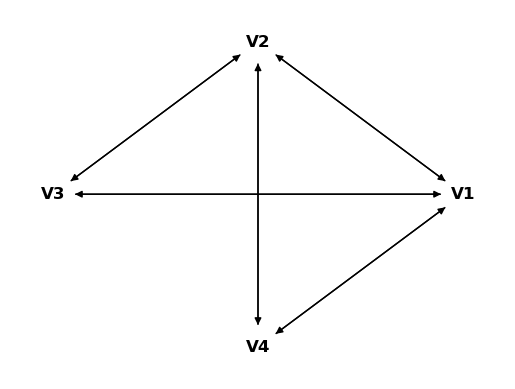

Number of CI tests performed: 45


In [7]:
cd = PC(data1, sig_level=0.05)
cd.fit()
g1 = cd.cpdag
plot_graph(g1)
print(f"Number of CI tests performed: {cd.nb_CI_tests}")

In [10]:
data2 = pd.read_csv("./Data/data2.csv", index_col=0)

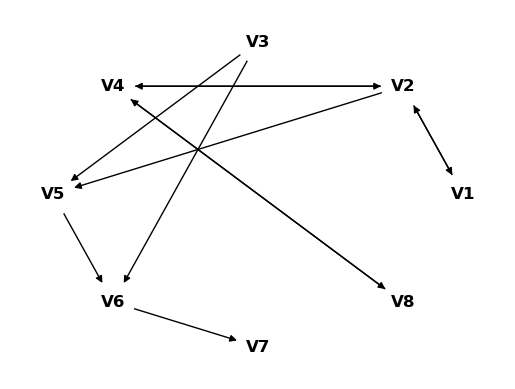

Number of CI tests performed: 166


In [11]:
cd = PC(data2, sig_level=0.05)
cd.fit()
g2 = cd.cpdag
plot_graph(g2)
print(f"Number of CI tests performed: {cd.nb_CI_tests}")

#### Provided Graphs

Running the code below allows you to check whether your PC implementation is correct. The graphs `g1_true` and `g2_true` correspond to the expected results for `data1` and `data2`. If your skeleton and edge orientations match these graphs, congratulations! If not, you can either try to fix your implementation or continue with the rest of the exercise using the provided `g1_true` and `g2_true`.

In [12]:
g1_true = nx.DiGraph([("V1","V2"), ("V1","V3"), ("V1","V4"), ("V2","V1"), ("V2","V3"), ("V2","V4"), ("V3","V1"), ("V3","V2"), ("V4","V1"), ("V4","V2")])
g2_true = nx.DiGraph([("V1","V2"), ("V2","V1"), ("V3","V5"), ("V2","V5"), ("V2","V4"), ("V4","V2"), ("V4","V8"), ("V8","V4"), ("V5","V6"), ("V6","V7"), ("V3","V6")])


def check_graph(true_graph, test_graph):
    true_skel = set(frozenset(e) for e in true_graph.edges)
    test_skel = set(frozenset(e) for e in test_graph.edges)
    print("Skeleton : correct" if true_skel == test_skel else "Skeleton : incorrect")
    print("Orientations : correct" if set(true_graph.edges) == set(test_graph.edges) else "Orientations : incorrect")

print("-"*20)
print("g1 :")
check_graph(g1_true, g1)
print("-"*20)
print("g2 :")
check_graph(g2_true, g2)


--------------------
g1 :
Skeleton : correct
Orientations : correct
--------------------
g2 :
Skeleton : correct
Orientations : correct


### From this point on, please use `g1_true` and `g2_true` as the basis for the rest of your work. 

The code below allows you to display these two graphs.


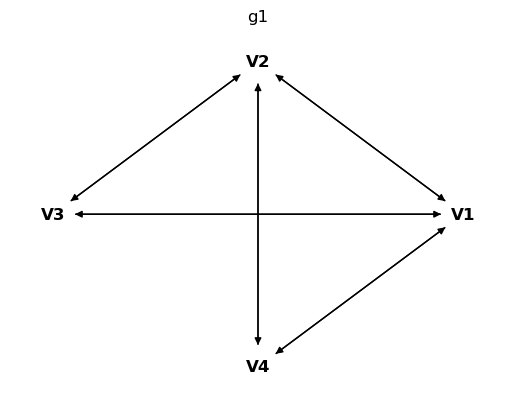

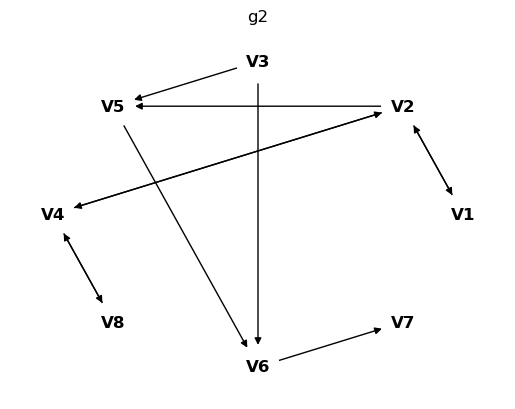

In [13]:
plot_graph(g1_true, title = "g1")
plot_graph(g2_true, title = "g2")

#### Question 3 (4 pts)

Based on the results obtained above, answer the following questions:

1. In graph `g1`, how should the edge between $V_1$ and $V_2$ be interpreted? How should the absence of edge between $V_3$ and $V_4$ be interpreted?

2. In graph `g2`, specify which PC algorithm rule was used to orient each of the following edges:
   - (a) $V_3 \rightarrow V_5$
   - (b) $V_6 \rightarrow V_7$
   - (c) $V_3 \rightarrow V_6$

3. According to graph `g2`, is it possible that the true underlying DAG $\mathcal{G}$ contains the following directed edges:
   - (a) $V_4 \rightarrow V_2 \rightarrow V_1$?
   - (b) $V_8 \rightarrow V_4 \leftarrow V_2$?


#### Answers
1. It means that $V_1$ and $V_2$ are adjacents in the skelleton but the algorithm didn't find a set $S$ such that $V_1$ is independant of $V_2$ knowing $S$. The absense of edge between $V_3$ and $V_4$ means the contrary. Thus, they are not adjacents in the skelleton i.e no links in the compatible DAGs. 

2.
   (a) # $R_0$ 
   (b) # $R_1$
   (c) # $R_2$
   
3. (a) # Yes because $V_4$ - $V_2$ and $V_2$ - $V_1$ aren't directed 
   (b) # No, because we would necessarly have this collider thanks to $R_0$

## Incorporating some background knowledge

An expert provides you with the following background knowledge about `g1`:  
*"Given my knowledge of the underlying causal mechanisms, it is **impossible** for the causal DAG to contain the orientations $V_3 \to V_2$ and $V_2 \to V_4$."*

#### Question 4 (1 pt):

Taking this background knowledge into account, plot `g1`.


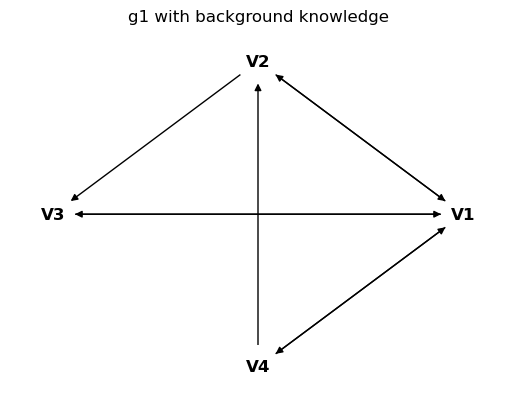

In [15]:

g1_bg = g1_true.copy()
g1_bg.remove_edge("V3", "V2")  # V3 -> V2 is impossible => orient as V2 -> V3
g1_bg.remove_edge("V2", "V4")  # V2 -> V4 is impossible => orient as V4 -> V2

plot_graph(g1_bg, title="g1 with background knowledge")

#### Question 5 (1 pt):

Based on the updated graph you obtained, is it possible to orient any additional edges? If so, which ones, and what reasoning leads to these orientations?

#### Answer

Yes. From the updated graph we have $V_2 \to V_3$ (directed), $V_4 \to V_2$ (directed), and $V_1 - V_2$, $V_1 - V_3$, $V_1 - V_4$ (undirected).

- $V_1 \to V_3$ by Rule 2: $V_1 - V_3$ is undirected and $V_1 - V_2 \to V_3$ provides a directed path from $V_2$ to $V_3$. Since $V_1 - V_2$ and $V_2 \to V_3$, to avoid creating a new v-structure we orient $V_1 \to V_3$.

- $V_1 \to V_2$ and $V_1 \to V_4$ by acyclicity: since $V_4 \to V_2$ is directed, orienting $V_2 \to V_1$ together with $V_1 \to V_4$ would create a cycle $V_1 \to V_4 \to V_2 \to V_1$. Similarly, orienting $V_4 \to V_1$ together with $V_1 \to V_2$ would create a cycle $V_4 \to V_1 \to V_2$ which contradicts $V_4 \to V_2$. Therefore the only acyclic orientation is $V_1 \to V_2$ and $V_1 \to V_4$.

So, all remaining undirected edges can be oriented: $V_1 \to V_2$, $V_1 \to V_3$, and $V_1 \to V_4$. The resulting graph is fully directed with $V_1$ as the root cause.

## On sparsity

#### Question 6 (1 pt):
An expert has informed you that the graph `g2` should be sparser (i.e., contain fewer edges). 

1. What action would you take to incorporate this information into the PC algorithm?  
2. What is the output of the PC algorithm for `data2` in this case?

#### Answer

1.

In [ ]:
# 2. TODO: New output of the PC algorithm for data2

## Unmeasured confounder

Consider the following DAG (run the cell to visualize it), and assume that $U$ is unobserved (typical example for the use of the front-door criterion).

In [ ]:
dag = nx.DiGraph()
dag.add_edges_from([
    ("X", "Z"),
    ("Z","Y"),
    ("U","X"),
    ("U","Y")
])
plot_graph(dag, unmeasured=["U"])

#### Question 7 (1 pt):

If we run the PC algorithm on the observed data (variables $\{X, Y, Z\}$), what would we obtain?  

*Note: You are not asked to run the algorithm; simply consider we observed data from $\{X, Y, Z\}$ generated from this SCM and describe the expected output of the PC algorithm under standard assumptions of constraint based causal discovery.*

#### Answer

## *Bonus Questions (+3 pts)*

1. An expert told you that there is a hidden common cause between $V_6$ and $V_8$ in `g2`. Do you think his knowledge is compatible with the observed distribution of `data2`? Explain.

2. Suppose that the data now come from a discrete SCM instead of the linear SCM (1), for example following the binary SCM:  

$$
V_i \sim \text{Bin}\bigg(\text{logit}^{-1}\Big(\sum_{V_j \in Pa(V_i, \mathcal G)}\alpha_{j,i}V_j\Big)\bigg), \quad \text{where Bin}(\cdot) \text{ denotes a Bernoulli law.}
$$  

Is the PC algorithm that we implemented suitable for this type of data? If yes, justify your answer; if not, what modifications would be required?  

3. With the PC algorithm, we obtain a point estimate of the causal structure (without any measure of uncertainty), yet the independence tests may be subject to errors with finite sample sizes. Suppose we want to assess the uncertainty that a variable $V_k$ is a neighbor of a variable $V_l$ (i.e., that $V_k \in Ne(V_l, \mathcal G)$). Propose a strategy to evaluate this uncertainty based on our sample.


#### Answers

1.

2.

3.